# 04 - Tournament Simulation & Outcome Visualizations

Monte Carlo simulate the full 48-team 2026 World Cup, then explore the results with a set of advanced outcome visualizations from `wcpredictor.visualization`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from wcpredictor.config import default_config
from wcpredictor.data import load_matches, load_teams, load_groups
from wcpredictor.data.preprocess import build_training_matches, team_match_counts

config = default_config()
plt.rcParams["figure.figsize"] = (9, 4.5)

from wcpredictor.models import PoissonModel
from wcpredictor.simulation import TournamentSimulator
from wcpredictor import visualization as viz
import numpy as np

In [2]:
tr = build_training_matches(load_matches(config), config)
poisson = PoissonModel(config).fit(tr)
groups = load_groups(config)
sim = TournamentSimulator(poisson, groups, config)
report = sim.run(n_simulations=5000)
report.table.head(12)

,team,group,p_advance,p_round_of_16,p_quarterfinal,p_semifinal,p_final,p_winner,p_group_1st,p_group_2nd,p_group_3rd,p_group_4th
0,Argentina,J,0.9750,0.7648,0.5468,0.3888,0.2594,0.1684,0.7372,0.1866,0.0600,0.0162
1,France,I,0.9184,0.6716,0.4514,0.2856,0.1704,0.1028,0.5324,0.2770,0.1352,0.0554
2,Spain,H,0.9560,0.6780,0.4422,0.2676,0.1580,0.0820,0.5778,0.3060,0.0876,0.0286
3,Brazil,C,0.9118,0.6158,0.3698,0.2270,0.1286,0.0718,0.4368,0.3464,0.1692,0.0476
4,Croatia,L,0.9212,0.6384,0.4022,0.2450,0.1386,0.0706,0.4800,0.2990,0.1770,0.0440
5,USA,D,0.9090,0.6056,0.3708,0.2204,0.1232,0.0658,0.5466,0.2560,0.1304,0.0670
6,Morocco,C,0.9094,0.5996,0.3636,0.2050,0.1118,0.0568,0.4138,0.3526,0.1810,0.0526
7,Mexico,A,0.9400,0.6168,0.3512,0.1914,0.0942,0.0452,0.5864,0.2618,0.1114,0.0404
8,England,L,0.8724,0.5486,0.3182,0.1646,0.0806,0.0402,0.3238,0.3564,0.2474,0.0724
9,Germany,E,0.9486,0.6064,0.3340,0.1690,0.0880,0.0388,0.6428,0.2298,0.0912,0.0362


## The title race

A lollipop chart of each contender's probability of lifting the trophy.

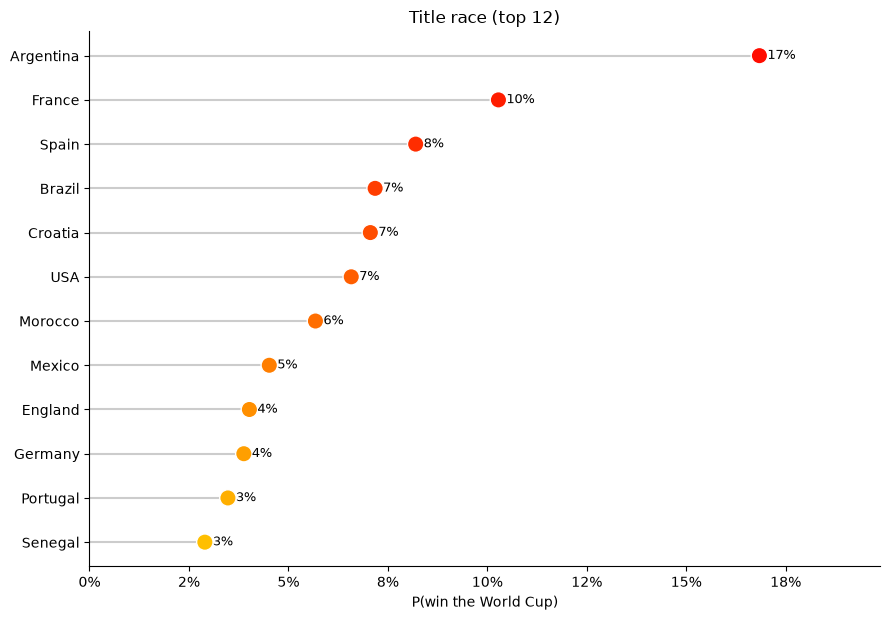

In [3]:
viz.plot_title_race(report, top_n=12)
plt.tight_layout(); plt.show()

## Full finish distribution

The headline outcome chart: every bar spans 0-100% and is split into the *mutually exclusive* ways a team's tournament can end, from a group-stage exit (left) to champion (right, gold). This shows a team's entire range of plausible results at once.

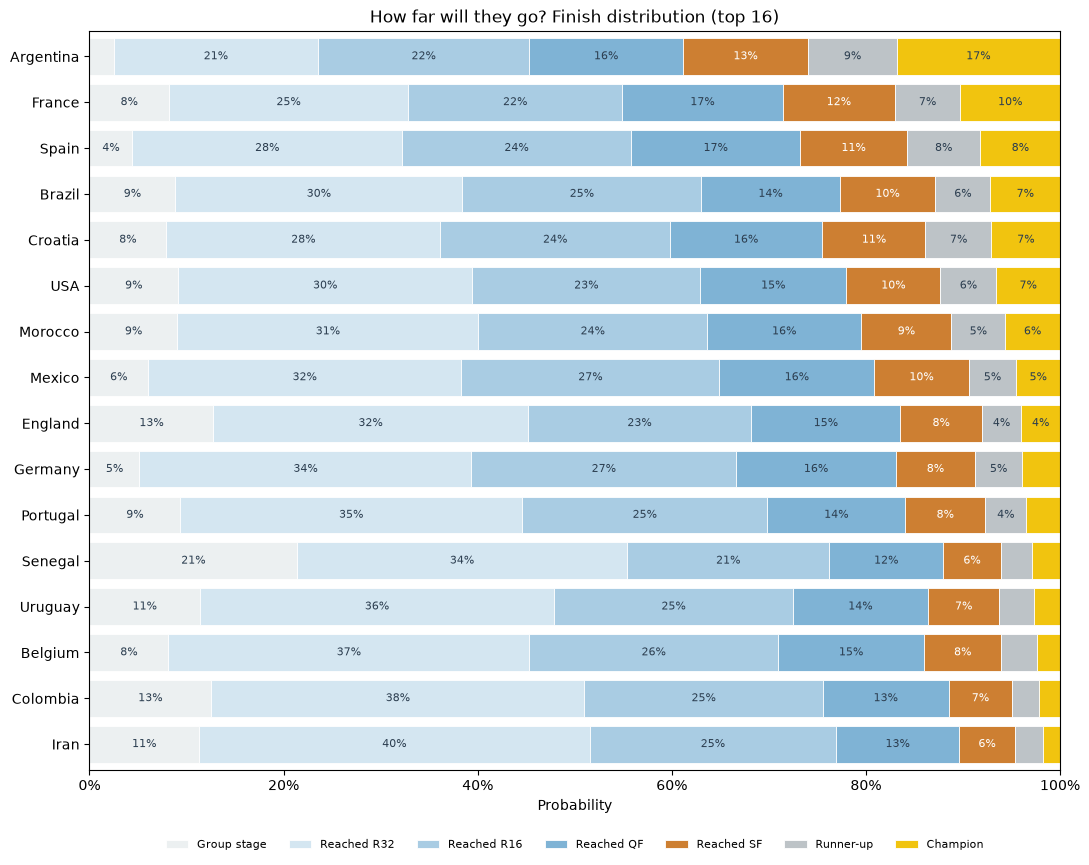

In [4]:
viz.plot_outcome_distribution(report, top_n=16)
plt.tight_layout(); plt.show()

## Reaching each stage (heatmap)

Cumulative probability of reaching each round.

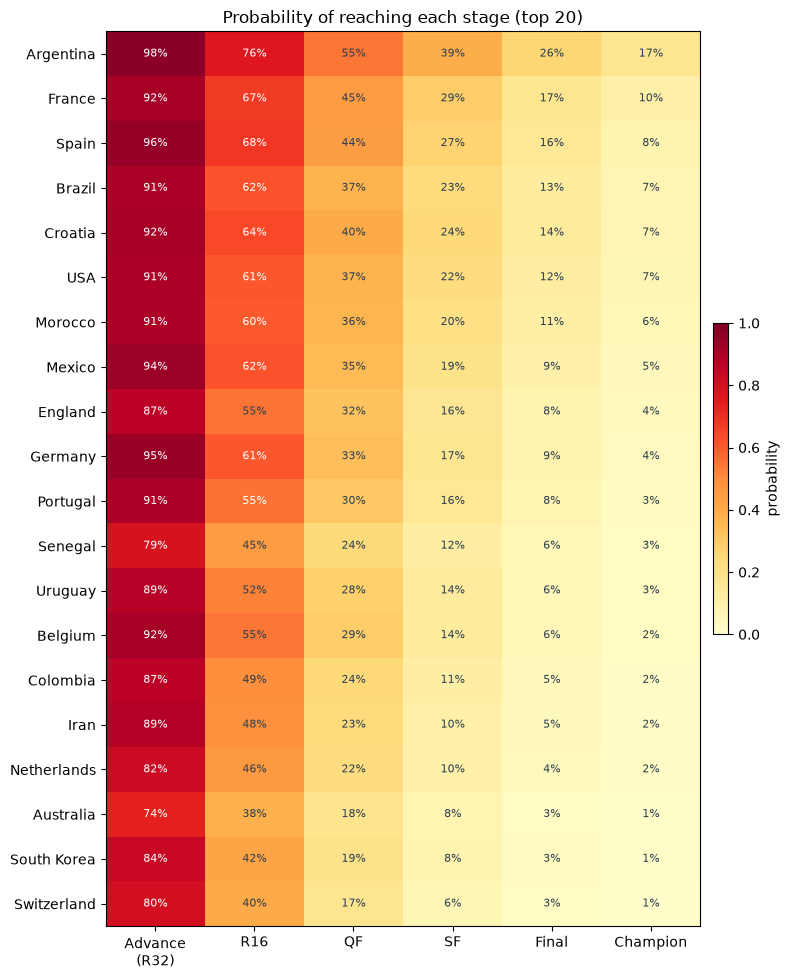

In [5]:
viz.plot_stage_heatmap(report, top_n=20)
plt.tight_layout(); plt.show()

## Group-stage outcomes

Probability of each team finishing 1st / 2nd / 3rd / 4th in their group (only the top two are guaranteed to advance; the best eight third-placed teams also progress).

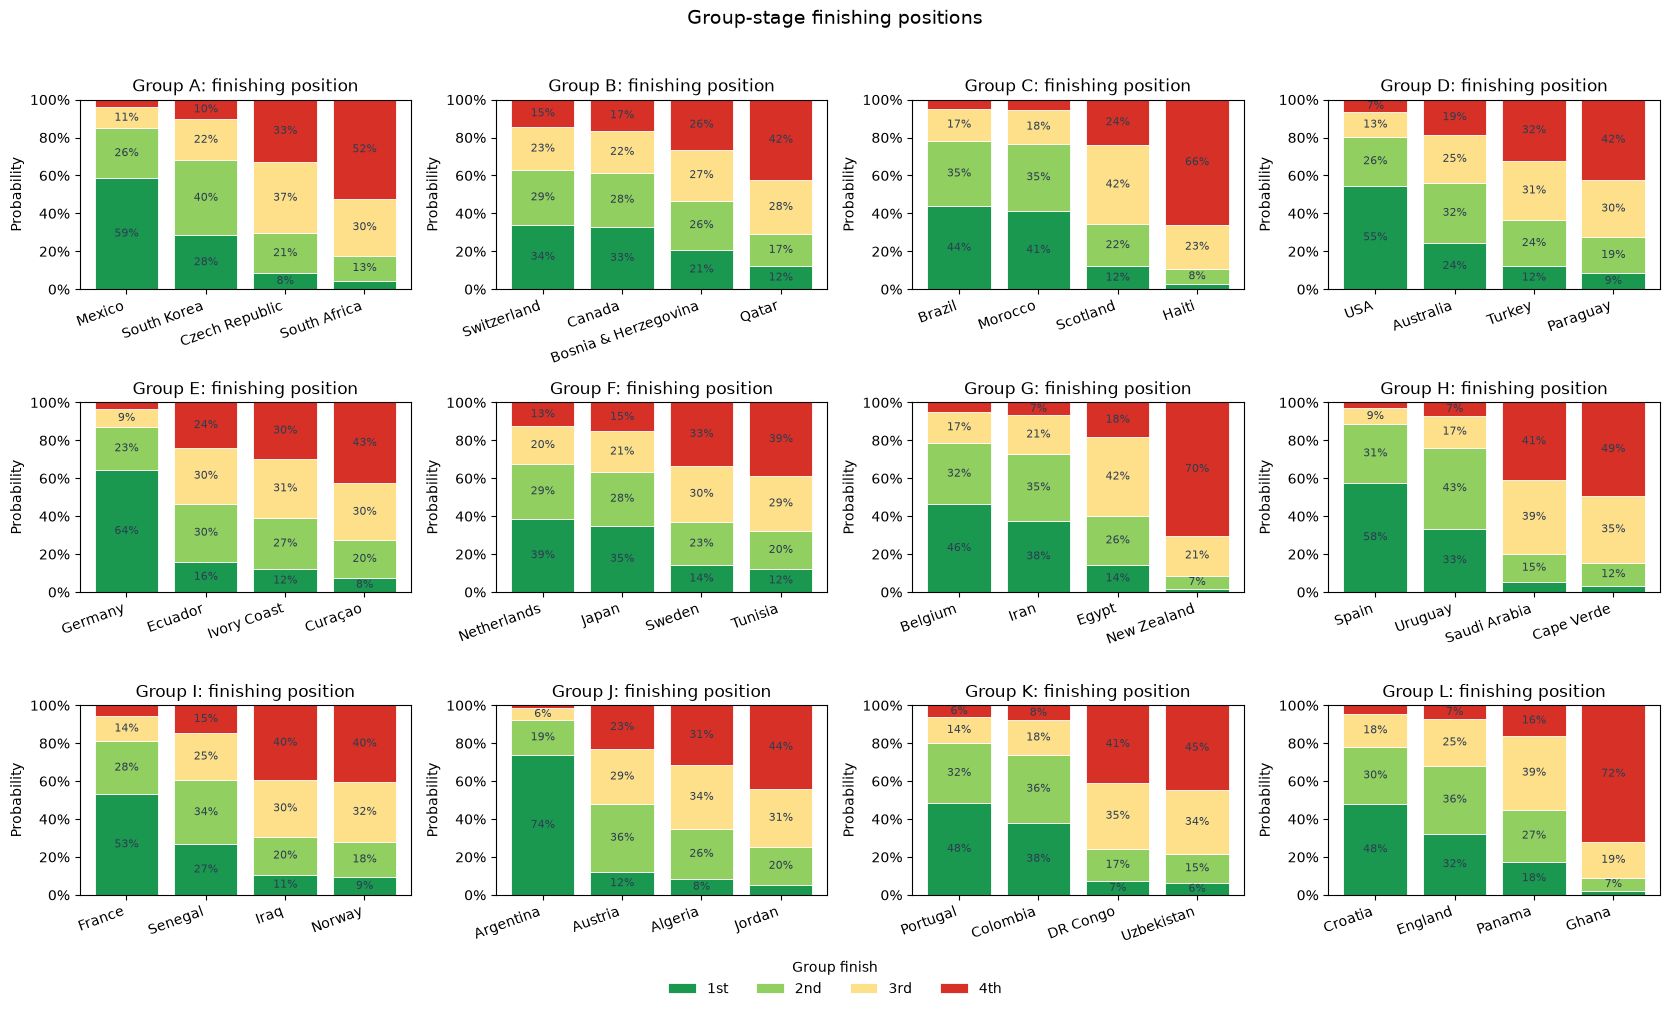

In [6]:
viz.plot_group_grid(report)
plt.show()

## Zoom into a single group

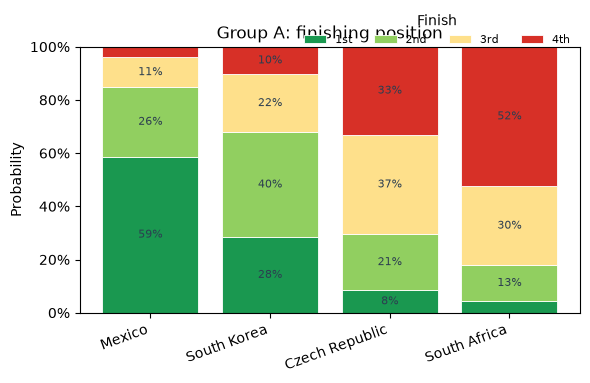

In [7]:
first_group = sorted(report.table['group'].unique())[0]
viz.plot_group_outcomes(report, first_group)
plt.tight_layout(); plt.show()

## One simulated tournament (example bracket)

A single random realization of the whole event.

In [8]:
rng = np.random.default_rng(7)
result = sim.simulate_once(rng)
print('Champion:    ', result['champion'])
print('Finalists:   ', sorted(result['reached']['final']))
print('Semifinalists:', sorted(result['reached']['semifinal']))

Champion:     Spain
Finalists:    ['Spain', 'USA']
Semifinalists: ['Argentina', 'Iran', 'Spain', 'USA']


## Most likely finish per team

The single most probable outcome for each of the favourites.

In [9]:
from wcpredictor.simulation.tournament import EXACT_OUTCOMES
label_map = dict(EXACT_OUTCOMES)
keys = [k for k, _ in EXACT_OUTCOMES]
dist = report.outcome_distribution()
dist['most_likely'] = dist[keys].idxmax(axis=1).map(label_map)
dist['p_most_likely'] = dist[keys].max(axis=1)
dist.sort_values('champion', ascending=False)[['team', 'group', 'most_likely', 'p_most_likely', 'champion']].head(12)

,team,group,most_likely,p_most_likely,champion
0,Argentina,J,Reached R16,0.2180,0.1684
1,France,I,Reached R32,0.2468,0.1028
2,Spain,H,Reached R32,0.2780,0.0820
3,Brazil,C,Reached R32,0.2960,0.0718
4,Croatia,L,Reached R32,0.2828,0.0706
5,USA,D,Reached R32,0.3034,0.0658
6,Morocco,C,Reached R32,0.3098,0.0568
7,Mexico,A,Reached R32,0.3232,0.0452
8,England,L,Reached R32,0.3238,0.0402
9,Germany,E,Reached R32,0.3422,0.0388
